# Gene loadings evaluation

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import random
import torch

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

# single cell libraries
import scanpy as sc
import squidpy as sq

# InterScale
import InterScale as interscale
from InterScale._paths import FIG_PATH
from InterScale.config import load_config

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` inste

## A. Load paths

In [2]:
BASE_DIR_PROJECT = "/lustre/groups/ml01/workspace/sara.jimenez/InterScale/"
CFG_DUAL_LEGNINI = os.path.join(BASE_DIR_PROJECT, "configs/legnini23_regr_node_DualCombined_genes.yaml")
RESULTS_DIR = os.path.join(BASE_DIR_PROJECT, "results")

## B. Load trained model

In [3]:
import random
import numpy as np
import torch

def set_full_reproducibility(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_full_reproducibility(42)

In [4]:
cfg = load_config(CFG_DUAL_LEGNINI)
cfg

CfgNode({'wandb': CfgNode({'use': False, 'project_name': 'GTLongRange_Legnini23'}), 'model': CfgNode({'n_embed': 16, 'local_component': CfgNode({'name': 'GCN', 'parameters': CfgNode({'hidden_dim': 256, 'num_layers': 2, 'dropout_local': 0.1})}), 'global_component': CfgNode({'name': 'self-attn-transformer', 'parameters': CfgNode({'n_heads': 4, 'dim_feedforward': 256, 'dropout_global': 0.1, 'activation_func': 'relu', 'num_layers': 2, 'max_seq_len': 4299, 'long_range_attention': False, 'type_gex_embedding': None}), 'latent_obsm_key': None}), 'save': None, 'loss': None, 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1, 'dual_decoder': True})}), 'optim': CfgNode({'accelerator': 'cpu', 'lr': 0.001, 'lr_scheduler': 'CosineWarmupScheduler', 'lr_warmup': 20, 'lr_max_epochs': 100, 'wd': 0.0001, 'loss': 'SmoothL1', 'seed': 44, 'cross_corr': 'cell', 'n_epochs': 100, 'early_stopping': True}), 'dataset': CfgNode({'h5ad_data': '/lustre/groups/ml01/projects/2024_s

In [5]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [6]:
import numpy as np
zero_expression_cells = np.array((adata.X.sum(axis=1) == 0)).flatten()
print(f"Nr. of zero expression cells: {zero_expression_cells.sum()}")
nonzero_cells = np.array((adata.X.sum(axis=1) != 0)).flatten()
adata = adata[nonzero_cells].copy()

Nr. of zero expression cells: 648


In [7]:
model_name = "legnini23/model_dual_decoder/dual_legnini23_regr_node_44_GCN_self-attn-transformer_model"

In [8]:
interscale.model.CombinedModel._setup_anndata(
    adata = adata, 
    prediction_task = cfg.dataset.prediction_task, 
    layer_key = cfg.dataset.layer_key, 
    sample_key_list = cfg.dataset.sample_key, 
    prediction_obs =  cfg.dataset.prediction_obs, 
    group_key = cfg.dataset.group_label, 
    view_registry = False
)

dual_combined_model = interscale.model.CombinedModel.load(
    os.path.join(RESULTS_DIR, "legnini23/model_dual_decoder"), 
    adata, 
    cfg,
    model_name="dual_legnini23_regr_node_44_GCN_self-attn-transformer_model",
    local_component = True, 
    global_component = True, 
)

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Loading model from /lustre/groups/ml01/workspace/sara.jimenez/InterScale/results/legnini23/model_dual_decoder/dual_legnini23_regr_node_44_GCN_self-attn-transformer_modelmodel.pt
Try with .ckpt extension.
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


In [9]:
print(dual_combined_model)

## C. Gene level evaluation

In [10]:
result = dual_combined_model.get_model_output(adata)

Load GEX from .layers/log1p_norm


In [11]:
result

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred_local', '_y_pred_global'

### Gene loadings analysis

standardize gene loadings meaning = change in gene g (in gene SD units) per 1 SD increase in latent dimension k.

In [12]:
from InterScale.evaluation import gene_loadings

In [13]:
gene_loadings(
    result,
    dual_combined_model,
    local_latent_key = "_global_emb",
    global_latent_key = "_global_emb",
    layer_key="log1p_norm",
)

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix'
    varm: '_local_std_gene_loadings', '_global_std_gene_loadings'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred_local', '_y_pred_global'

### 0. Are the embedding dimensions linearly independent?

For the local and global embeddings separately: 

- Linear independence of embedding dimensions = columns of Z are linearly independent, i.e. rank(Z) == n_dims
- Visual: Plot the correlation between each embedding dimension. If the matrix is almost diagonal, we can assume linea independence. 

In [14]:
from InterScale.evaluation import latent_rank_report, pl_latent_correlation

In [15]:
# Check rank:
rep_global = latent_rank_report(result, "_global_emb")
rep_local  = latent_rank_report(result, "_local_emb")
print(rep_global)
print(rep_local)

{'z_key': '_global_emb', 'n_obs': 43114, 'n_dims': 16, 'rank': 16, 'linearly_independent': True}
{'z_key': '_local_emb', 'n_obs': 43114, 'n_dims': 16, 'rank': 16, 'linearly_independent': True}


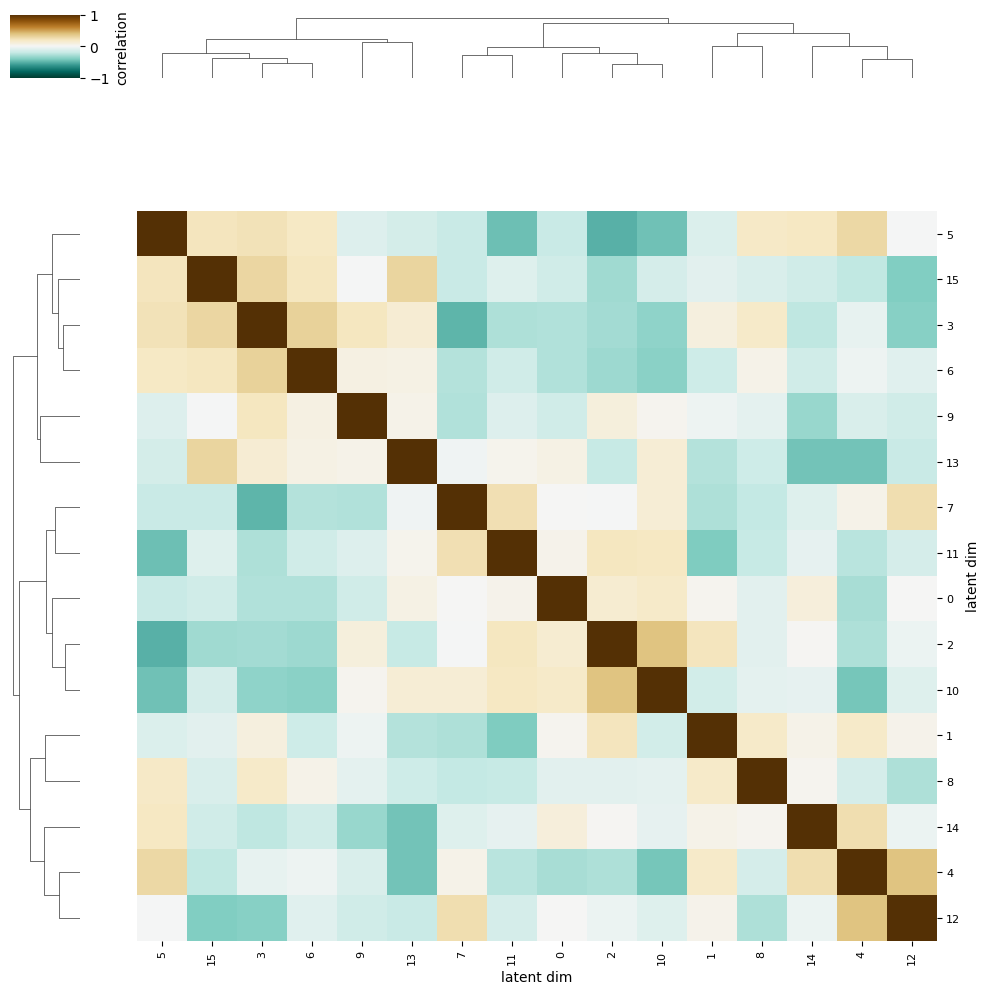

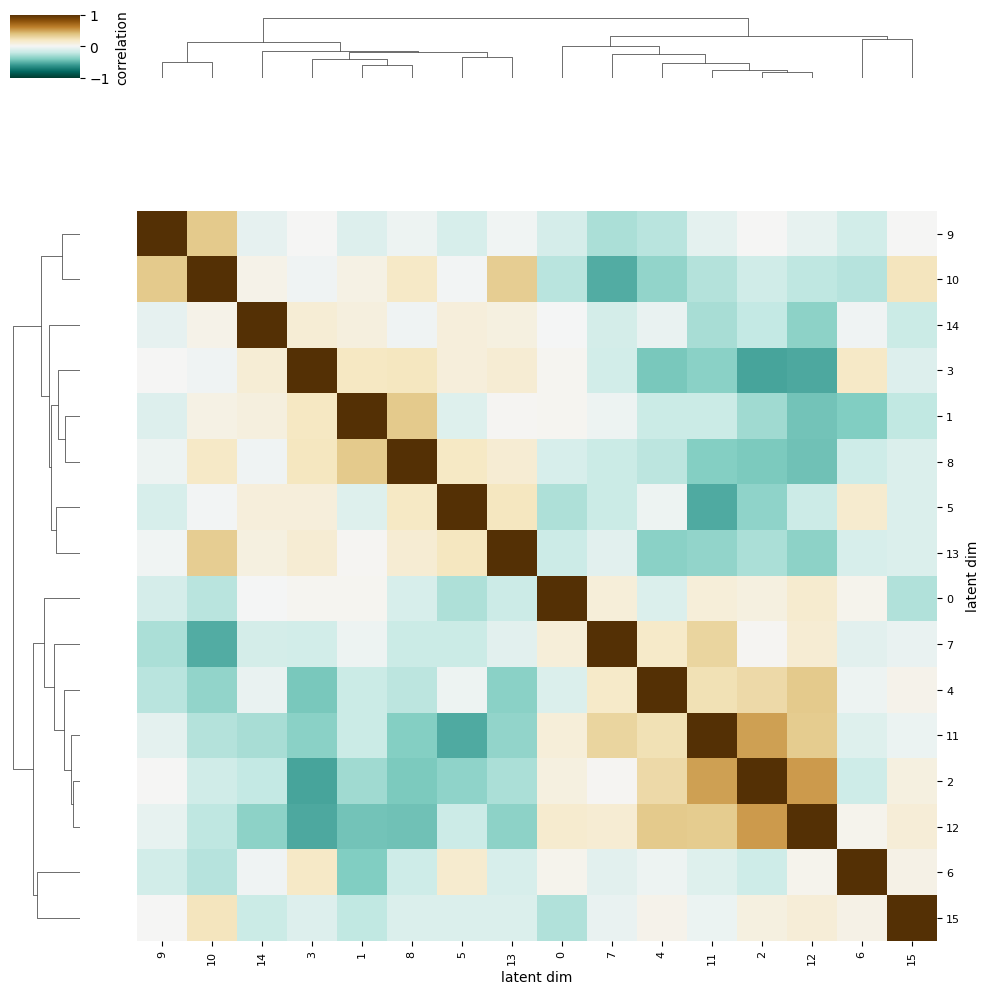

In [16]:
# Visual Pearson correlation beteween embedding dimensions

pl_latent_correlation(result, z_key="_local_emb", vmax=1.0, cmap="BrBG_r")
pl_latent_correlation(result, z_key="_global_emb", vmax=1.0, cmap="BrBG_r")

### 1. Filter dimensions e per scale

We use per-dimension contribution to variance of reconstructed gene expression.  

Because we're using a linear decoder and we have uncorrelated embedding dimensions then: 

```Var(Ŷ) ~ tr((W^TW)Cov(H))```

In [ ]:
from InterScale.evaluation import pl_dim_importance_elbow_stdexpr

In [ ]:
pl_dim_importance_elbow_stdexpr(
    result,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    mode="full",               # "full" (uses Corr(Z) off-diagonals) or "diag" (assumes dims uncorrelated)
    use_ratio=True,              # True -> normalize to sum to 1 (if total>0)
    cumulative_cutoff=0.60,      # vertical line at smallest #dims reaching cutoff (only meaningful if use_ratio and total>0)
    spacing=1,
    figsize=(4,3),
    fontsize=12,
    title=None,
    show=True,
)

In [ ]:
pl_dim_importance_elbow_stdexpr(
    result,
    s_key="_local_std_gene_loadings",
    z_key="_local_emb",
    mode="full",               # "full" (uses Corr(Z) off-diagonals) or "diag" (assumes dims uncorrelated)
    use_ratio=True,              # True -> normalize to sum to 1 (if total>0)
    cumulative_cutoff=0.60,      # vertical line at smallest #dims reaching cutoff (only meaningful if use_ratio and total>0)
    spacing=1,
    figsize=(4, 3),
    fontsize=12,
    title=None,
    show=True,
)

### 2. Filter genes 

standardize gene loadings meaning = change in gene g (in gene SD units) per 1 SD increase in latent dimension k.  

- Expression filtering:
| Argument   | Effect                               |
| ---------- | ------------------------------------ |
| `X_layer`  | Expression matrix used for filtering |
| `min_frac` | Remove rare genes                    |
| `min_sd`   | Remove low-variance genes            |

- Scoring choices
| Argument                 | Meaning                                |
| ------------------------ | -------------------------------------- |
| `rank_by="loading"`      | Pure decoder sensitivity               |
| `rank_by="loading_x_sd"` | Favor highly variable genes            |
| `residualize=True`       | Use only unique component of dimension |

- Specificity control
| Argument                   | Meaning                              |
| -------------------------- | ------------------------------------ |
| `enforce_specificity`      | Force genes to be dimension-specific |
| `specificity_mode="ratio"` | max/second criterion                 |
| `specificity_min`          | How strict the specificity must be   |

 
gene_by_dim_heatmap interpretation:

So:

Dark brown → strong positive association with that dimension

Dark green → strong negative association

Near white → little association

In [ ]:
global_dim = [11, 1, 7, 5, 10]
local_dim = [13, 14, 1, 0, 7, 2]

In [ ]:
from InterScale.evaluation import get_genes_dim

In [ ]:
df_global, ax = get_genes_dim(
    result,
    which="global",
    dims=global_dim,
    n_top=20,
    X_layer="log1p_norm",
    min_frac=0.1,
    rank_by="loading_x_sd",
    enforce_specificity=True,
    specificity_min=1.5,
    #residualize=True,
    plot=True,
    figsize=(3.3, 5),
)

In [ ]:
df_local, ax = get_genes_dim(
    result,
    which="local",
    dims=local_dim,
    n_top=20,
    X_layer="log1p_norm",
    min_frac=0.1,
    enforce_specificity=True,
    rank_by="loading_x_sd",
    specificity_min=1.5,
    #residualize=True,
    plot=True,
    figsize=(3.3, 5),
)

In [ ]:
global_genes = df_global.index 
local_genes = df_local.index

shared = global_genes.intersection(local_genes)
unique_local = local_genes.difference(global_genes)
unique_global = global_genes.difference(local_genes)

print("Shared:", shared.tolist())
print("Unique local:", unique_local.tolist())
print("Unique global:", unique_global.tolist())

In [ ]:
result.X = result.layers['log1p_norm'].copy()

In [ ]:
local_genes = ['CUX2','GLI1','TUBB3','ISL1']
global_genes =  ['FOXO6','NEUROG2','HHIP','PROM1']

In [ ]:
for gene in global_genes:
    sq.pl.spatial_scatter(result, 
                          library_key='sample',
                          library_id=['slide4_B2-2'],
                          color = gene,
                          cmap = 'viridis',
                          ncols=1,
                          shape= None, 
                          frameon=False,
                          dpi=300,
                          figsize=(2, 2),
                          #save=f'{gene}_spatial_scatter.png',
                         )

In [ ]:
shh_test = result[result.obs['sample'] == 'slide4_B2-2'].copy()

### 3. Identify gene programs

In [ ]:
import gseapy as gp

In [ ]:
enr_global = gp.enrichr(
    gene_list=unique_global.tolist(),
    gene_sets="GO_Biological_Process_2025",
    organism="Human",   # or "Mouse"
    outdir=None,
)
enr_global.results.head()

In [ ]:
enr_local = gp.enrichr(
    gene_list=unique_local.tolist(),
    gene_sets="GO_Biological_Process_2025",
    organism="Human",   # or "Mouse"
    outdir=None,
)
enr_local.results.head()

In [ ]:
df_local = enr_local.results
df_global = enr_global.results

In [ ]:
top_local = df_local.sort_values("Adjusted P-value").head(6)
top_global = df_global.sort_values("Adjusted P-value").head(6)

In [ ]:
df_local["group"] = "Local"
df_global["group"] = "Global"

combined = pd.concat([
    df_local.sort_values("Adjusted P-value").head(6),
    df_global.sort_values("Adjusted P-value").head(6)
])

combined["-log10(padj)"] = -np.log10(combined["Adjusted P-value"])

In [ ]:
import seaborn as sns

combined = combined.sort_values("-log10(padj)", ascending=False)

palette = {
    "Global": "#27828E",
    "Local": "#EE9B00"
}

plt.figure(figsize=(8,4))

sns.barplot(
    data=combined,
    y="Term",
    x="-log10(padj)",
    hue="group",
    palette=palette,
    legend=False
)

plt.xlabel("-log10(adjusted p-value)", fontsize=10)
plt.ylabel("", fontsize=10)
#plt.title("GO enrichment: global vs local embeddings", fontsize=10)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

#plt.legend(title="", fontsize=10)

plt.tight_layout()
#plt.savefig("figures/gene_programs.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib as mpl

# --- Prepare dataframe ---
plot_df = combined.copy().reset_index(drop=True)

# --- Compute Gene Ratio ---
plot_df["gene_ratio"] = plot_df["Overlap"].str.split("/").apply(
    lambda x: int(x[0]) / int(x[1])
)

# --- Clip extreme values (stabilize color contrast) ---
clip_max = 0.05  # adjust if needed
plot_df["gene_ratio_plot"] = plot_df["gene_ratio"].clip(upper=clip_max)

# --- Signed values for diverging bars ---
plot_df["signed_log10"] = plot_df["-log10(padj)"]
plot_df.loc[plot_df["group"] == "Local", "signed_log10"] *= -1

# --- Sort by absolute significance ---
plot_df = plot_df.sort_values(
    by="signed_log10",
    key=lambda s: s.abs(),
    ascending=True
).reset_index(drop=True)

# --- Colormap setup ---
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(
    vmin=plot_df["gene_ratio_plot"].min(),
    vmax=plot_df["gene_ratio_plot"].max()
)

# --- Create figure ---
fig, ax = plt.subplots(figsize=(8, 4.5))

# --- Plot bars ---
ax.barh(
    y=plot_df["Term"],
    width=plot_df["signed_log10"],
    color=cmap(norm(plot_df["gene_ratio_plot"])),
    edgecolor="none",
    height=0.7
)

# --- Center line ---
ax.axvline(0, color="black", linewidth=1)

# --- Symmetric x-limits ---
max_val = plot_df["-log10(padj)"].max()
ax.set_xlim(-max_val * 1.1, max_val * 1.1)

# --- Labels ---
ax.set_xlabel("-log10(adjusted p-value)", fontsize=10)
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

# --- Optional group labels ---
ax.text(-max_val * 1.05, len(plot_df) - 0.5, "Local", 
        ha="left", va="bottom", fontsize=10)
ax.text( max_val * 1.05, len(plot_df) - 0.5, "Global", 
        ha="right", va="bottom", fontsize=10)

# --- Colorbar ---
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Gene Ratio", fontsize=10)

# --- Layout & save ---
plt.tight_layout()
plt.savefig("../../../figures/gene_programs_diverging_gene_ratio.png",
            dpi=300, bbox_inches="tight")
plt.show()